# Анализ и визуализация полученных данных

Проведя первичный анализ данных предоставленного на наличие дубликатов, мы обогатили и обработали данные. Таким образом, мы получили большой набор данных, анализ которого мы будем проводить.  

#### Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import seaborn as sns

In [2]:
dataset = pd.read_csv('datasets/titles_cleaned.tsv', sep='\t')
genres = pd.read_csv('datasets/genres_cleaned.tsv', sep='\t')
actors = pd.read_csv('datasets/actors_cleaned.tsv', sep='\t')
directors = pd.read_csv('datasets/directors_cleaned.tsv', sep='\t')
countries = pd.read_csv('datasets/countries_cleaned.tsv', sep='\t')

#### Для начала посмотрим на то, какие типы контента представлены в нашем датасете

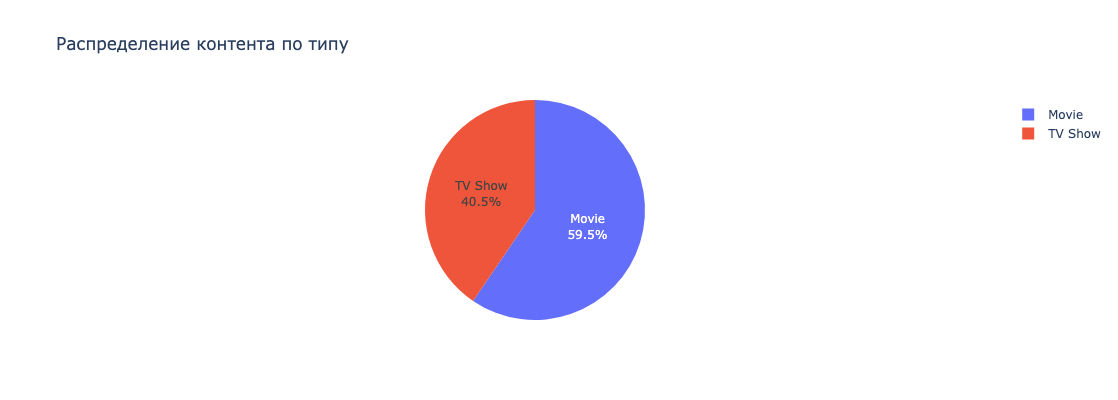

In [3]:
fig = go.Figure(data=[go.Pie(labels=dataset['type'].value_counts().reset_index()['type'], values=dataset['type'].value_counts().reset_index()['count'], textinfo='percent+label', hole=0)])
fig.update_layout(title='Распределение контента по типу', width=600, height=400)
fig.show()

### Посмотрим на распределение длительностей фильмов

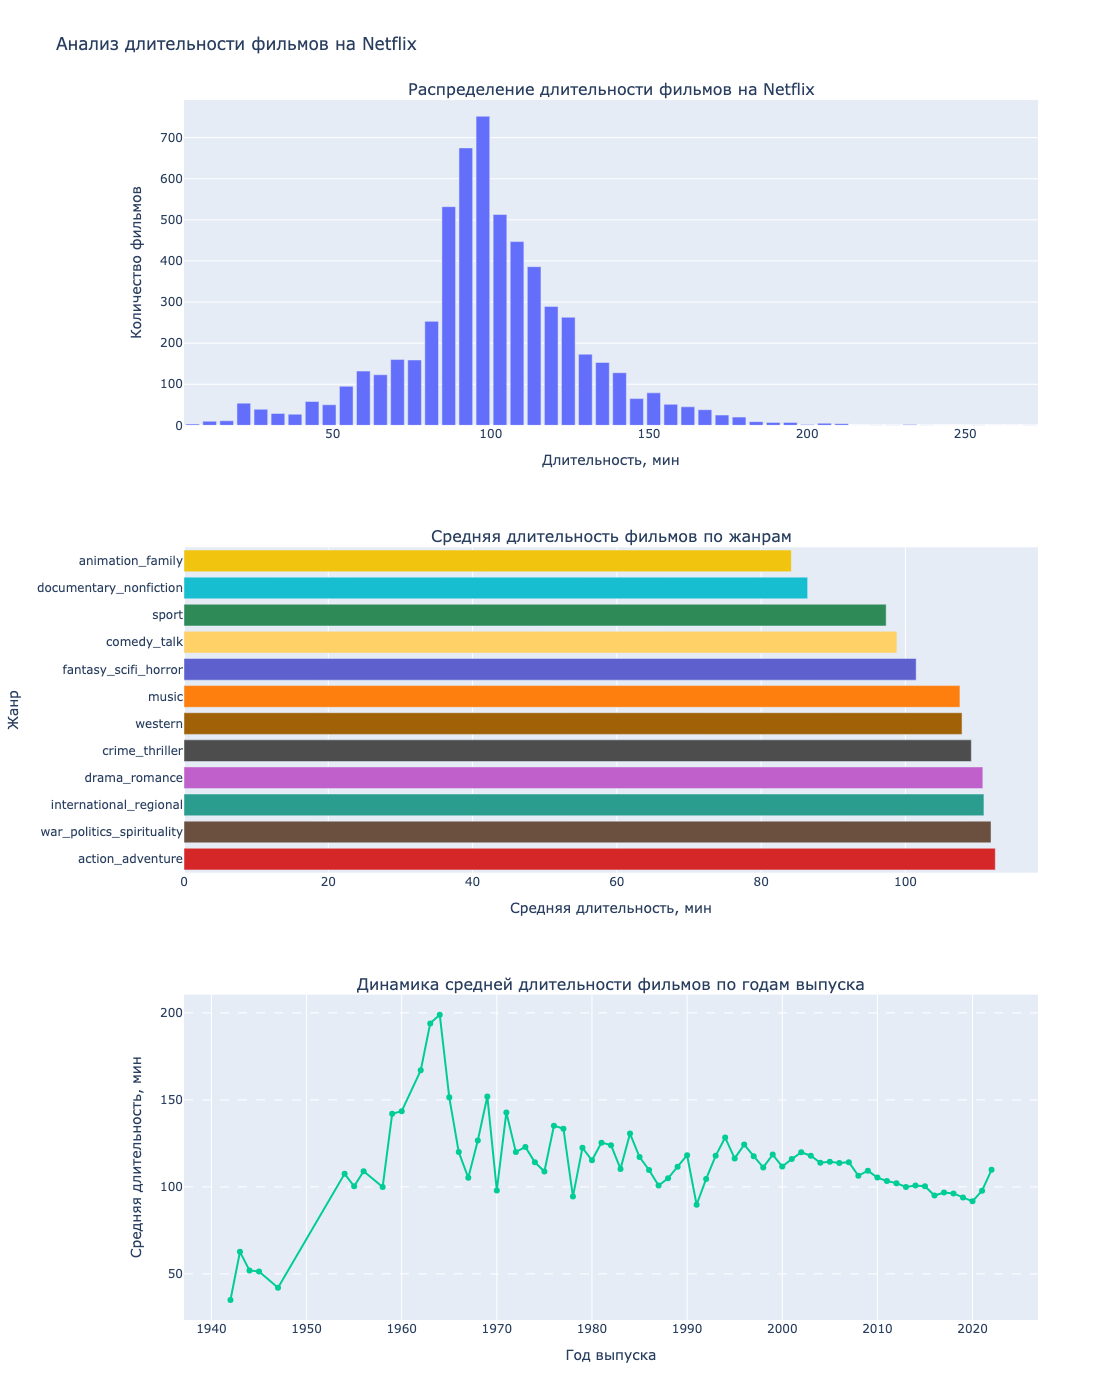

In [4]:
movies = dataset[dataset['type'] == 'Movie'].copy().dropna(subset='duration')
movies_genres = movies.merge(genres[['title_id', 'genre_name']], on='title_id', how='left')

genre_duration = movies_genres.dropna(subset=['genre_name']).groupby('genre_name', as_index=False)['duration'].mean().sort_values('duration', ascending=False)
year_duration = movies.groupby('release_year', as_index=False)['duration'].mean().sort_values('release_year')

genre_palette = {
    'action_adventure': '#d62728',
    'war_politics_spirituality': '#6b4f3f',
    'international_regional': '#2a9d8f',
    'drama_romance': '#c061cb',
    'crime_thriller': '#4d4d4d',
    'western': '#a16207',
    'music': '#ff7f0e',
    'fantasy_scifi_horror': '#5e60ce',
    'comedy_talk': '#ffd166',
    'sport': '#2e8b57',
    'documentary_nonfiction': '#17becf',
    'animation_family': '#f1c40f',
}

bar_colors = [genre_palette[g] for g in genre_duration['genre_name']]

hist_y, hist_x = np.histogram(movies['duration'], bins=50)
hist_centers = (hist_x[:-1] + hist_x[1:]) / 2

fig = make_subplots(rows=3, vertical_spacing=0.1, subplot_titles=['Распределение длительности фильмов на Netflix', 'Средняя длительность фильмов по жанрам', 'Динамика средней длительности фильмов по годам выпуска'])

fig.add_trace(go.Bar(x=hist_centers, y=hist_y), row=1, col=1)
fig.update_xaxes(title_text='Длительность, мин', row=1, col=1)
fig.update_yaxes(title_text='Количество фильмов', row=1, col=1)

fig.add_trace(go.Bar(x=genre_duration['duration'], y=genre_duration['genre_name'], orientation='h', marker={'color' : bar_colors}), row=2, col=1)
fig.update_xaxes(title_text='Средняя длительность, мин', row=2, col=1)
fig.update_yaxes(title_text='Жанр', row=2, col=1)


fig.add_trace(go.Scatter(x=year_duration['release_year'], y=year_duration['duration'], mode='lines+markers'), row=3, col=1)
fig.update_xaxes(title_text='Год выпуска', row=3, col=1)
fig.update_yaxes(title_text='Средняя длительность, мин', row=3, col=1, showgrid=True, griddash='dash')

fig.update_layout(height=1400, width=1100, title='Анализ длительности фильмов на Netflix', showlegend=False)
fig.show()

Основная масса фильмов имеет продолжительность 80-130 минут, очень короткие  и очень длинные фильмы - редкость. Индустрия ориентирована на массовый формат потребления, фильмы такой длительности универсальны для широкого потребления. Каталог в основном состоит из фильмов стандратной длины: 1:20-1:40. Такая продолжительность фильма удобна для большинства потребителей - не слишком мало (достаточно наполненный сюжет) и не слишком много (можно посмотреть за 1 раз)

Также заметны отличия в средней продолжительности фильмов разных жанров, например - мультики имеют продолжительность в среднем менее полутора часов, в то время как, боевики - почти 2 часа

Если рассматривать среднюю продолжительность по годам выпуска, то фильмы выпущенные ранее 2000 года - не очень репрезентативны: фильмы снимались редко, а в каталог нетфликса они попадали ещё реже. С 2000 года наблюдается тендеция на снижение средней длительности - подобный контент все чаще становится продуктом широкого потребления, а массы требуют больше контента за меньше времени, а еще лучше рилсы

### Посмотрим на респределение количества сезонов у сериалов 

In [5]:
season_counts = dataset[dataset['type'] == 'TV Show']['duration'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Bar(x=season_counts.index, y=season_counts.values, text=season_counts.values))
fig.update_layout(title='Распределение количества сезонов у сериалов на Netflix', xaxis_title='Количество сезонов', yaxis_title='Количество сериалов', yaxis_type='log', width=1100, height=600)
fig.update_xaxes(tickmode='array', tickvals=list(range(int(season_counts.index.min()), int(season_counts.index.max()))))

fig.show()


1) Мы предполагаем, Netflix ориентирован на запуск и тестирование новых проектов.
2) Видна высокая роль мини-сериалов или сериалов с законченной историей. То есть зрителю проще начать смотреть сериал с низким порогом входа (чтобы посмотреть сезон N не нужно смотреть N-1 предыдущих сезонов).
3) Жесткий отбор на продолжение истории - малое количество сериалов признаются успешными, чтобы получить следующие части.
4) Длинные франшизы - бриллиант. Часто имеют большую стратегическую ценность, так как увеличивают удержание пользователей и формируют привычку возвращатсья на платформу снова и снова.

Итак, каталог сериалов Netflix сильно смещен в сторону мини-сериалов. Это указывает на стратегию широкой воронки запуска сериалов и выборочного продления только наиболее успешных проектов.

### Проанализируем временные признаки - год релиза и дату добавления на платформу

In [6]:
df_dates = dataset.copy()

df_dates['date_added'] = pd.to_datetime(df_dates['date_added'], errors='coerce')
df_dates['date_added_year'] = df_dates['date_added'].dt.year

release_type_counts = df_dates[df_dates['release_year'] >= 2000].dropna(subset=['release_year', 'type']).groupby(['release_year', 'type']).size().reset_index(name='count')
added_type_counts = df_dates.dropna(subset=['date_added_year', 'type']).groupby(['date_added_year', 'type']).size().reset_index(name='count')

fig = go.Figure()

fig.add_trace(go.Bar(x=release_type_counts[release_type_counts['type'] == 'Movie']['release_year'], y=release_type_counts[release_type_counts['type'] == 'Movie']['count'], name='Movies'))
fig.add_trace(go.Bar(x=release_type_counts[release_type_counts['type'] == 'TV Show']['release_year'], y=release_type_counts[release_type_counts['type'] == 'TV Show']['count'], name='TV Shows'))
fig.add_trace(go.Bar(x=added_type_counts[added_type_counts['type'] == 'Movie']['date_added_year'], y=added_type_counts[added_type_counts['type'] == 'Movie']['count'], name='Movies', visible=False))
fig.add_trace(go.Bar(x=added_type_counts[added_type_counts['type'] == 'TV Show']['date_added_year'], y=added_type_counts[added_type_counts['type'] == 'TV Show']['count'],name='TV Shows',visible=False))

updatemenus = {
    'type' : 'buttons',
    'x' : 1.1,
    'y' : 1.4,
    'buttons' : [
        {
            'label' : 'Release Year',
            'method' : 'update',
            'args' : [{'visible': [True, True, False, False]}, {'title': 'Распределение контента по году выпуска в разрезе по type', 'xaxis': {'title': 'Год выпуска'}, 'yaxis': {'title': 'Количество единиц контента'}}]
        },
        {
            'label' : 'Date Added',
            'method' : 'update',
            'args' : [{'visible': [False, False, True, True]}, {'title': 'Распределение контента по году добавления на Netflix в разрезе по type', 'xaxis': {'title': 'Год добавления'}, 'yaxis': {'title': 'Количество единиц контента'}}]
        },
    ]
},

fig.update_layout(title='Распределение контента по году выпуска в разрезе по type', xaxis_title='Год выпуска', yaxis_title='Количество единиц контента', updatemenus=updatemenus)

fig.show()

1) Обратившись в интернет, мы можем узнать, что Netflix начал расширирять свое присутствие на международном рынке 2015-2019 г.г. В этот период мы можем видеть положительную динамику количества добавленного и выпущенного контента. Вероятно, Netflix для выхода на новые рынки приобретал права на стриминг все более разнообразного контента.
2) Далее, видим нисходящий тренд после 2019 года. Данный упадок мог произойти на фоне стремительного развития конкурентов в виде Disney+, HBO Max, Amazon Prime Video.
3) Данный нисходящий тренд также может быть связан с начавшейся в конце 2019 г. пандемией. Значение достигает своего локального минимума в 2022 году, так как производство фильма процесс длительнный, из-за этого просадка происходит с задержкой.
4) Возможная причина нисходящего тренда 2023 г. - [забастовка гильдии сценаристов](https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%B1%D0%B0%D1%81%D1%82%D0%BE%D0%B2%D0%BA%D0%B0_%D0%93%D0%B8%D0%BB%D1%8C%D0%B4%D0%B8%D0%B8_%D1%81%D1%86%D0%B5%D0%BD%D0%B0%D1%80%D0%B8%D1%81%D1%82%D0%BE%D0%B2_%D0%A1%D0%A8%D0%90_(2023)). 

### Проведем анализ географии нашего датасета и посмотрим на языковую палитру

In [7]:
titles_countries = dataset.merge(countries[['title_id', 'country_name']], on='title_id', how='left').dropna(subset=['country_name'])
country_title_counts = titles_countries.groupby('country_name', as_index=False).agg(title_count=('title_id', 'nunique'))

fig = px.choropleth(country_title_counts, locations='country_name', locationmode='country names', color='title_count', hover_name='country_name', title='Распределение контента Netflix по странам производства')
fig.update_layout(width=1000, height=500, geo={'showframe' : False, 'landcolor' : "#CFC9C9"})
fig.show()

/var/folders/rb/jjbql8_n2svfm4_nn63dwtt40000gn/T/ipykernel_82864/2254806526.py:4: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



1) США - центр мирового кинематографа.  
2) Азия - густонаселенный регион с сильныой киноиндустрией, специализирующейся на локальные рынки.
3) Старая Европа заметны наравне с Азией, но не сопоставимы с США. Европейское кино - источник качественного контента, а также способ усиливать присутствие на развитом рынке.

Netflix строит глобальную библиотеку не за счет равномерного покрытия всех стран, а за счет концентрации на нескольких крупных мировых центрах. Данная стратегия повышает предсказуемость качества и востребованность контента.

In [8]:
language_counts = dataset['language'].dropna().value_counts()

language_share = language_counts / language_counts.sum()
main_languages = language_counts[language_share >= 0.01].copy()
main_languages.loc['Others'] = language_counts[language_share < 0.01].sum()

language_mapping = {
    'en': 'Английский',
    'ja': 'Японский',
    'ko': 'Корейский',
    'zh': 'Китайский',
    'fr': 'Французский',
    'es': 'Испанский',
    'hi': 'Хинди',
    'ru': 'Русский',
    'de': 'Немецкий',
    'tr': 'Турецкий',
    'tl': 'Тагальский',
    'it': 'Итальянский',
    'pt': 'Португальский',
    'Others': 'Другие (< 1%)'
}
language_labels = [language_mapping[lang] for lang in main_languages.index]

fig = go.Figure(data=[go.Pie(labels=language_labels, values=main_languages.values, textinfo='percent+label', sort=False, marker={'line' : {'color' : 'white', 'width' : 5}})])
fig.update_layout(title='Распределение контента по языкам', width=900, height=900)

fig.show()

Языковая структура библиотеки платформы достаточно обширна. Но имеет ярко выраженное англоязычное ядро. 

### Теперь посмотрим на пользовательские оценки и их количество

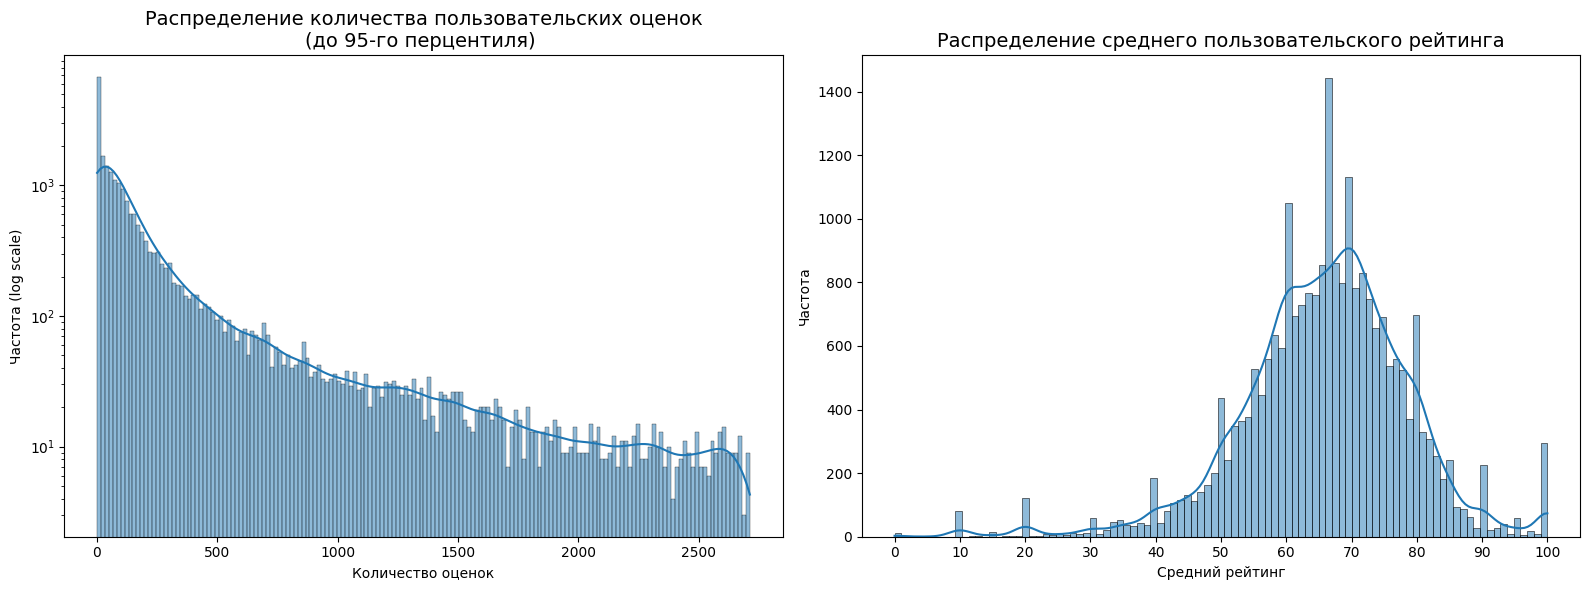

In [9]:
rating_data = dataset[['user_rating_size', 'user_rating_score']].dropna().copy()

q95 = rating_data['user_rating_size'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data=rating_data[(rating_data['user_rating_size'] > 0) & (rating_data['user_rating_size'] <= q95)], x='user_rating_size', kde=True, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Распределение количества пользовательских оценок\n(до 95-го перцентиля) ', fontsize=14)
axes[0].set_xlabel('Количество оценок')
axes[0].set_ylabel('Частота (log scale)')

sns.histplot(data=rating_data[(rating_data['user_rating_size'] > 0) & (rating_data['user_rating_size'] <= q95)], x='user_rating_score', kde=True, ax=axes[1])
axes[1].set_xticks(list(range(0, 110, 10)))
axes[1].set_title('Распределение среднего пользовательского рейтинга', fontsize=14)
axes[1].set_xlabel('Средний рейтинг')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

1) У подавляющегося числа тайтлов число оценок относительно небольшое. 
2) Основная масса контента воспринимается пользователями положительно.

Каталог Netflix, вероятно, сочетает небольшое число массовых хитов с большим объемом нишевого, но приемлемо оцененного контента. Для платформы это означает потенциал роста не только через производство новых хитов, но и через более эффективное продвижение уже существующих качественных тайтлов с низкой вовлеченностью аудитории.

In [10]:
rating_relation = dataset[dataset['user_rating_size'] > 0][['user_rating_size', 'user_rating_score', 'type']].dropna(subset=['user_rating_size', 'user_rating_score', 'type']).copy()

fig = go.Figure()

fig.add_trace(go.Scatter(x=rating_relation[rating_relation['type'] == 'Movie']['user_rating_size'], y=rating_relation[rating_relation['type'] == 'Movie']['user_rating_score'], mode='markers', name='Movies',  marker={'size' : 6, 'opacity' : 0.5, 'color' : 'orange'}))
fig.add_trace(go.Scatter(x=rating_relation[rating_relation['type'] == 'TV Show']['user_rating_size'], y=rating_relation[rating_relation['type'] == 'TV Show']['user_rating_score'], mode='markers', name='TV Shows', marker={'size' : 6, 'opacity' : 0.5, 'color' : 'blue'}))

updatemenus = {
    'type' : 'buttons',
    'direction' : 'down',
    'x' : 1.1,
    'y' : 0.7,
    'buttons' : [
        {
            'label' : 'All titles',
            'args' : [
                {'visible': [True, True]},
                {'title': 'Связь между количеством пользовательских оценок и средним рейтингом: весь контент', 'showlegend': True}
            ]
        },
        {
            'label' : 'Movies',
            'args' : [
                {'visible': [True, False]},
                {'title': 'Связь между количеством пользовательских оценок и средним рейтингом: фильмы'}
            ]
        },
        {
            'label' : 'TV Shows',
            'args' : [
                {'visible': [False, True]},
                {'title': 'Связь между количеством пользовательских оценок и средним рейтингом: сериалы'}
            ]
        },
    ]
},

fig.update_layout(title='Связь между количеством пользовательских оценок и средним рейтингом: весь контент', xaxis_title='Количество оценок', yaxis_title='Средний рейтинг', xaxis_type='log', width=1100, height=650, updatemenus=updatemenus, showlegend=True)
fig.show()

Средний рейтинг без масштаба голосования, как на предыдущей визуализации, несильно информативен. Сериалы выглядят более сильным форматом с точки зрения оценок аудитории, в то время как фильмы реже дают стабильный результат. 

### Теперь посмотрим на две противоположности: на тайтлы с высокими средними, но малочисленными оценками и на тайтлы с большим количеством в среднем плохих оценок  
При наведении можно увидеть название фильма

In [11]:
geniuses = dataset[((dataset['user_rating_size'] <= 30) & (dataset['user_rating_size'] >= 2) & (dataset['user_rating_score'] >= 85))][['title', 'user_rating_size', 'user_rating_score']]
losers = dataset[(dataset['user_rating_size'] >= 100) & (dataset['user_rating_score'] <= 30)][['title', 'user_rating_size', 'user_rating_score']]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=geniuses['user_rating_score'],
    y=geniuses['user_rating_size'],
    mode='markers',
    name=f'Незамеченные шедевры',
    marker={'color' : 'green', 'size' : 10, 'line' : {'color' : 'white', 'width' : 1}},
    customdata=np.stack([geniuses['title']], axis=-1),
    hovertemplate='<b>%{customdata[0]}</b><br>Score: %{x:.2f}<br>Votes: %{y:.0f}'
))

fig.add_trace(go.Scatter(
    x=losers['user_rating_score'],
    y=losers['user_rating_size'],
    mode='markers',
    name=f'Общепризнанное.. (антоним к слову шедевр)',
    marker={'color' : 'red', 'size' : 10, 'line' : {'color' : 'white', 'width' : 1}},
    customdata=np.stack([losers['title']], axis=-1),
    hovertemplate='<b>%{customdata[0]}</b><br>Score: %{x:.2f}<br>Votes: %{y:.0f}'
))

fig.add_vline(x=85, line_dash='dash', line_color='green', line_width=1)
fig.add_vline(x=30, line_dash='dash', line_color='red', line_width=1)

fig.update_layout(title='Незамеченные шедевры и их противоположности по пользовательским рейтингам', width=1200, height=700)
fig.update_xaxes(title='Средняя пользовательская оценка', range=[0, 100], dtick=10)
fig.update_yaxes(title='Количество оценок', type='log')

fig.show()

### Мы все еще никак не использовали таблицу с актерами, так найдем действительно неочевидные структуры и зависимости в наших данных!

Выберем актера, например: **Nikolaj Coster-Waldau**, и построим граф связей: узлами будут актеры, которые когда либо играли в одном тайтле с **Nikolaj Coster-Waldau**, а ребро будет означать, что два актера играли вместе в одном тайтле, но не обязательно втроем с **Nikolaj Coster-Waldau**

соберем, граф, фото актеров с помощью API ***themoviedb***, сохраним это в таблицы и визуализируем в программе *Gephi*

In [233]:
from itertools import combinations
selected = 'Nikolaj Coster-Waldau'

selected_ids = actors[actors['name'] == selected]['actor_id'].unique()
selected_titles = actors[actors['actor_id'].isin(selected_ids)]['title_id'].unique()
node_actor_ids = actors[actors['title_id'].isin(selected_titles)]['actor_id'].unique()

nodes_out = actors[actors['actor_id'].isin(node_actor_ids)][['actor_id', 'name']].drop_duplicates().rename(columns={'actor_id': 'Id', 'name': 'Label'}).reset_index(drop=True)
sub = actors[actors['actor_id'].isin(node_actor_ids)][['title_id', 'actor_id']].drop_duplicates()

edges = []
for t in sub['title_id'].unique():
    acts = sub[sub['title_id'] == t]['actor_id'].unique()
    for i, j in combinations(sorted(acts), 2):
        edges.append((i, j))

edges_out = pd.DataFrame(edges, columns=['Source', 'Target']).drop_duplicates()

In [ ]:
import time
import requests

TMDB_READ_TOKEN = 'ТОКЕН БЫЛ НО МЫ ЕГО УБРАЛИ'

session = requests.Session()
session.headers.update({
    'Accept': 'application/json',
    'Authorization': f'Bearer {TMDB_READ_TOKEN}',
})

def search_person(name):
    url = 'https://api.themoviedb.org/3/search/person'
    params = {'query': name, 'language': 'en-US', 'page': 1}
    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    results = data.get('results', [])
    return results[0]

def download_image(image_path, target_path):
    url = f'https://image.tmdb.org/t/p/w500{image_path}'
    with session.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(target_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

nodes_out['tmdb_id'] = pd.NA
nodes_out['photo_path'] = pd.NA
nodes_out['photo_status'] = pd.NA

for idx, row in nodes_out.iterrows():
    actor_id = row['Id']
    name = row['Label']
    try:
        person = search_person(name)
        if not person:
            print(f'[{idx+1}/{len(nodes_out)}] Не найден: {name}')
            nodes_out.at[idx, 'photo_status'] = 'NOT_FOUND'
            continue

        profile_path = person.get('profile_path')
        person_id = person.get('id', '')
        tmdb_name = person.get('name', '')
        nodes_out.at[idx, 'tmdb_id'] = person_id

        if not profile_path:
            print(f'[{idx + 1}/{len(nodes_out)}] Нет фото: {name}')
            nodes_out.at[idx, 'photo_status'] = 'NO_PHOTO'
            continue

        filename = f'{actor_id}.png'
        filepath = 'photos/' + filename

        download_image(profile_path, filepath)

        
        nodes_out.at[idx, 'photo'] = filename
        nodes_out.at[idx, 'photo_status'] = 'OK'

        print(f'[{idx+1}/{len(nodes_out)}] OK: {name} -> {filename}')

        time.sleep(0.25)

    except Exception as e:
        print(f'[{idx + 1}/{len(nodes_out)}] Ошибка с {name}: {e}')
        nodes_out.at[idx, 'photo_status'] = 'ERROR'

nodes_out.to_csv('nodes.csv', index=False)
edges_out.to_csv('edges.csv', index=False)    

[1/60] OK: Gerard Butler -> a54125.png
[2/60] OK: Tom Cruise -> a86117.png
[3/60] OK: Jamie Foxx -> a91621.png
[4/60] OK: Guy Pearce -> a77749.png
[5/60] OK: Olga Kurylenko -> a14190.png
[6/60] OK: Carice van Houten -> a33089.png
[7/60] OK: Sam Shepard -> a70143.png
[8/60] OK: Ériq Ebouaney -> a79105.png
[9/60] OK: Jacki Weaver -> a23684.png
[10/60] OK: Annabelle Wallis -> a70741.png
[11/60] OK: Andrea Riseborough -> a20285.png
[12/60] OK: Juliette Binoche -> a67017.png
[13/60] OK: Gary Cole -> a41005.png
[14/60] OK: Lake Bell -> a67582.png
[15/60] OK: Emilia Clarke -> a60762.png
[16/60] OK: January Jones -> a33755.png
[17/60] OK: Morgan Freeman -> a16899.png
[18/60] OK: Aksel Hennie -> a62905.png
[19/60] OK: Synnøve Macody Lund -> a60804.png
[20/60] OK: Nikolaj Coster-Waldau -> a76142.png
[21/60] OK: Julie R. Ølgaard -> a60436.png
[22/60] OK: Kyrre Haugen Sydness -> a1018.png
[23/60] OK: Eduardo Noriega -> a69295.png
[24/60] OK: Stephen Rea -> a24212.png
[25/60] OK: Magaly Solier -> a

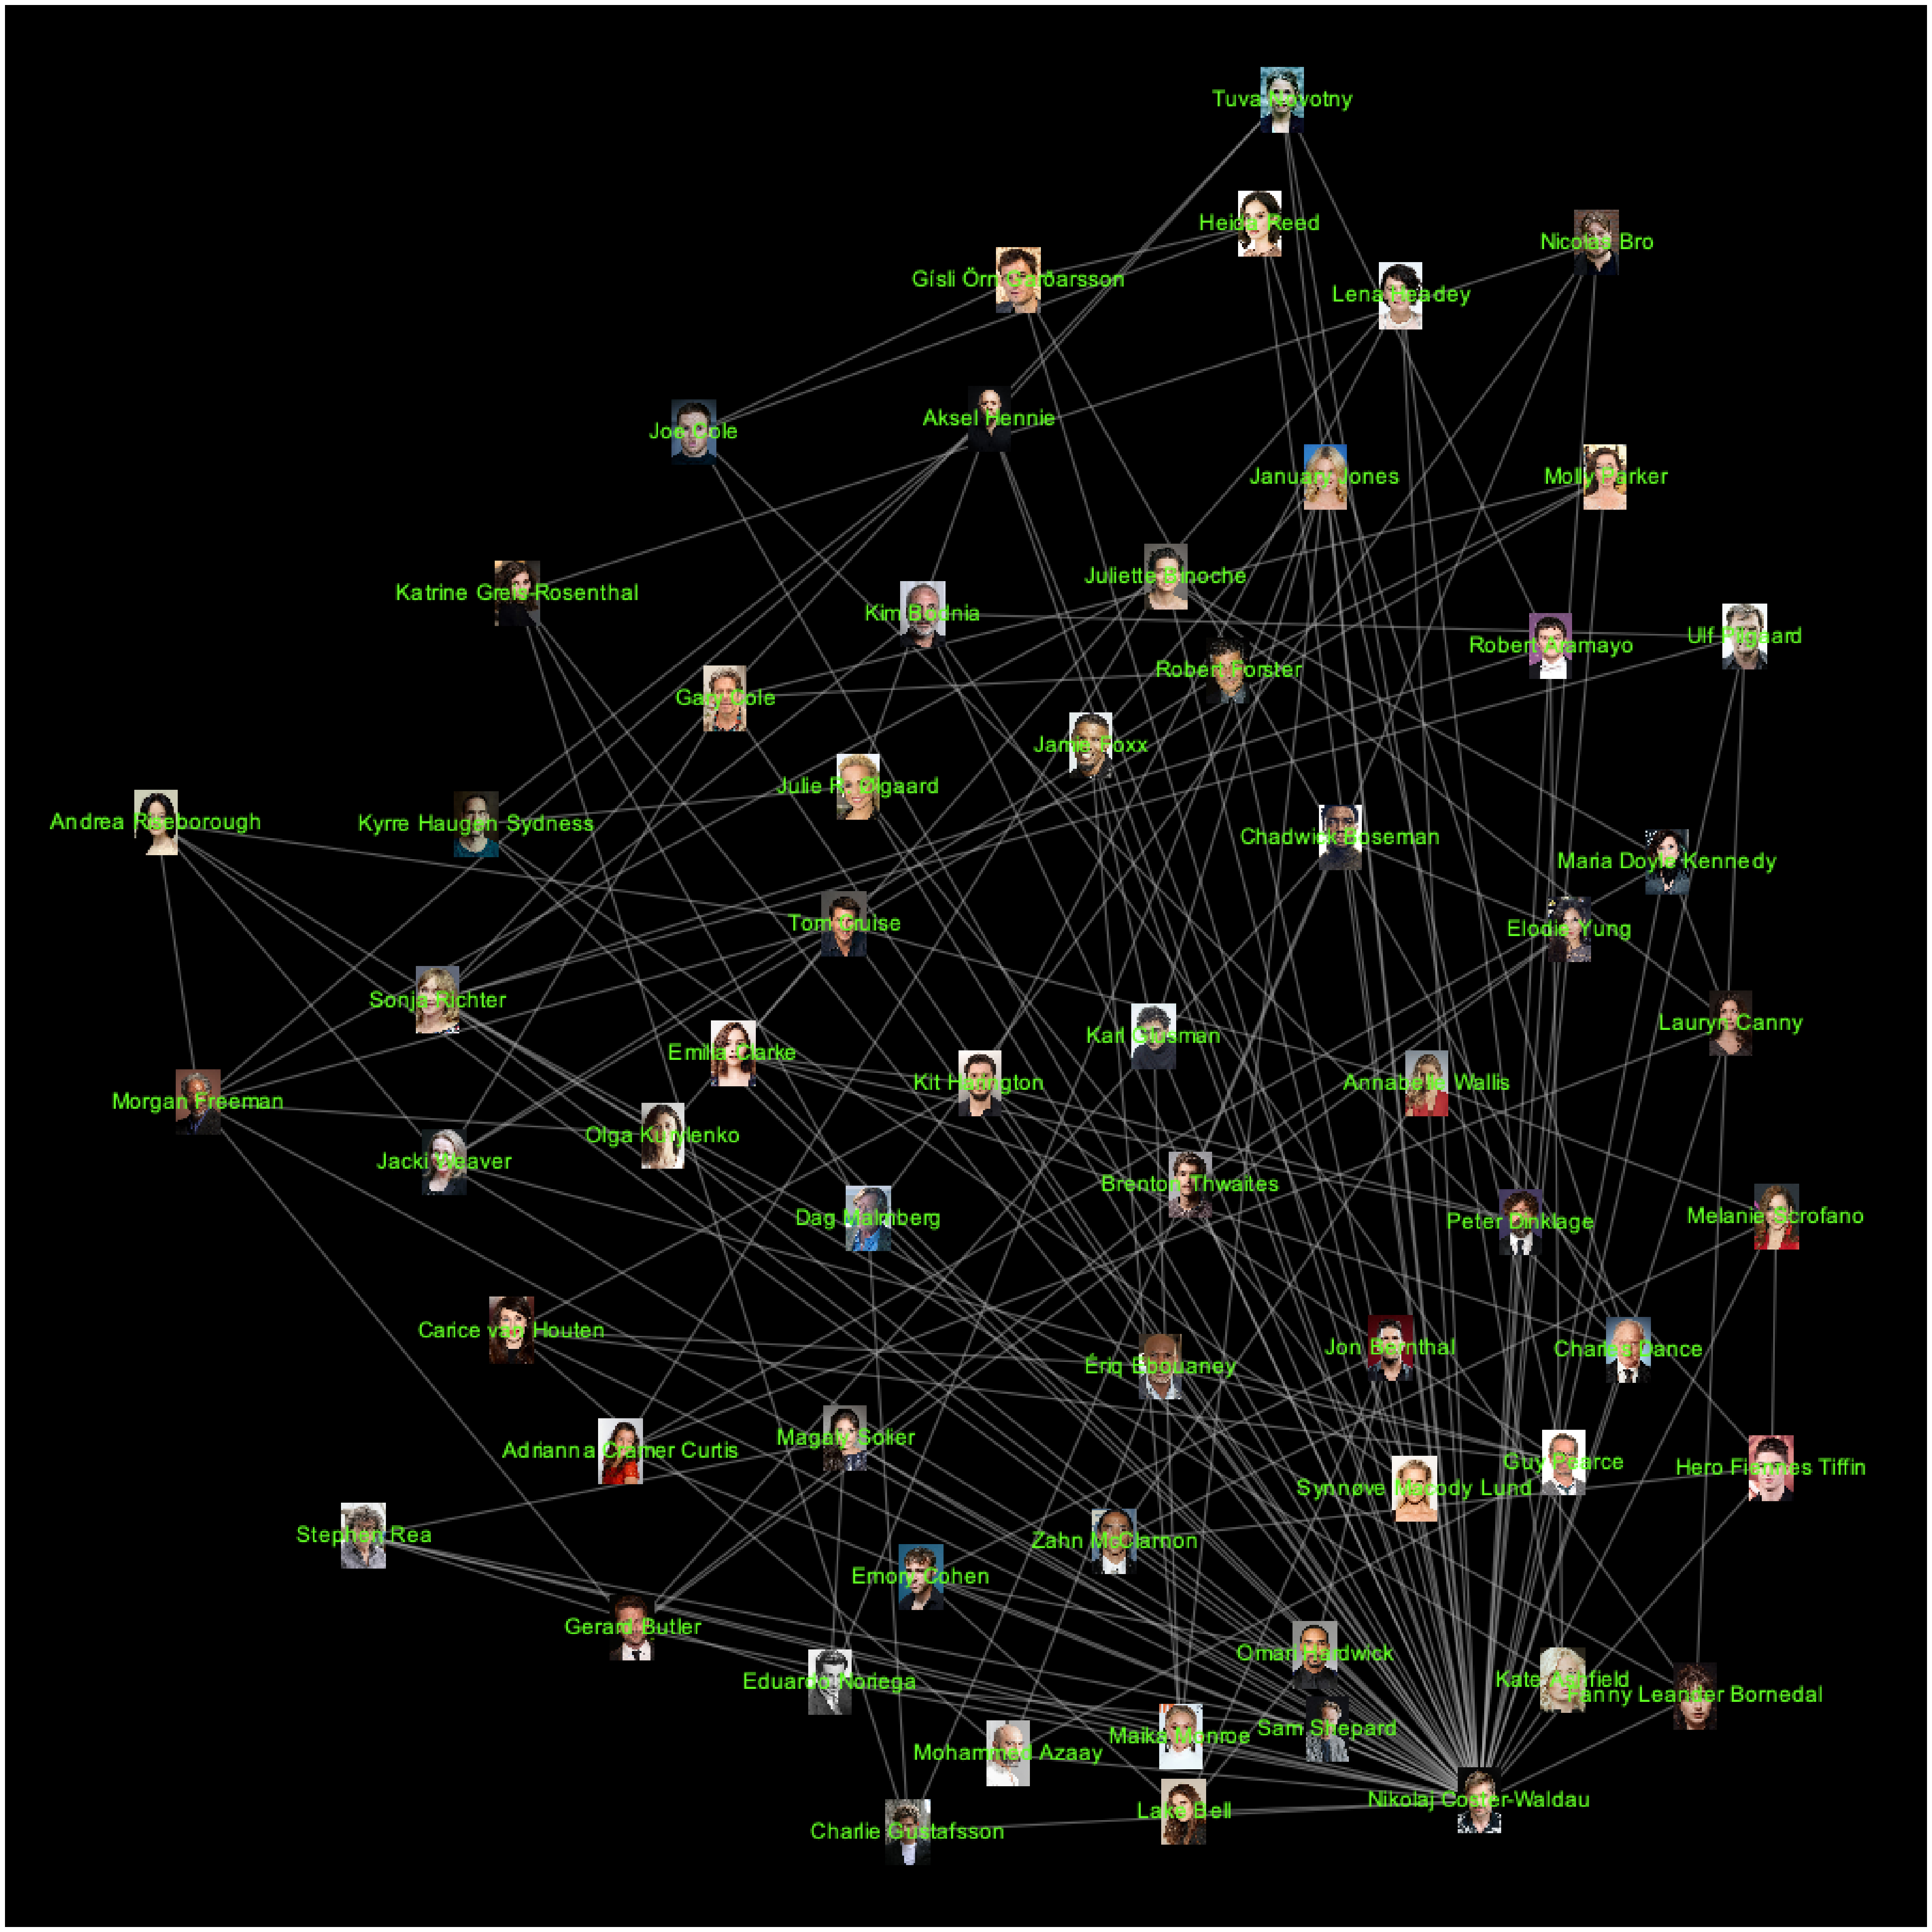

In [234]:
plt.figure(figsize=(50,50))
plt.imshow(plt.imread('f2.png'))
plt.axis('off');

### Теперь посмотрим на связь бюджета и кассовых сборов по фильма

In [22]:
movies_finance = dataset[dataset['type'] == 'Movie'][['budget', 'revenue', 'title']].dropna(subset=['budget', 'revenue'])
movies_finance = movies_finance[(movies_finance['budget'] > 1000) & (movies_finance['revenue'] > 1000)]

fig = go.Figure()

fig.add_trace(go.Scatter(x=movies_finance['budget'], y=movies_finance['revenue'], mode='markers', text=movies_finance['title'], marker={'opacity': 0.7, 'size': 5}, name='Фильмы'))
fig.add_trace(go.Scatter(x=[0, movies_finance['budget'].max()], y=[0, movies_finance['budget'].max()], mode='lines', line={'color': 'red'}, name='Граница окупаемости'))

fig.update_layout(title='Связь бюджета и кассовых сборов по фильмам', width=1200, height=600)
fig.update_xaxes(title='Бюджет, $')
fig.update_yaxes(title='Кассовые сборы')

fig.show()

In [23]:
movies_finance.corr(numeric_only=True)['revenue']['budget']

np.float64(0.748147258978121)

1) С ростом бюджет в среднем растут и кассовые сборы (корреляция 0.75). Это вполне логично: высокий бюджет часто характеризуется звездным кастом, качественными визуальными эффектами и анимацией, а также производственными мощностями.
2) Большая часть фильмов сосредоточена в зоне относительно небольших бюджетов и 

### Теперь взглянем на соотношение бюджетов и кассовых сборов фильмов

In [24]:
movies_finance['revenue_to_budget'] = movies_finance['revenue'] / movies_finance['budget']

fig = go.Figure()
fig.add_trace(go.Scatter(x=movies_finance['budget'], y=movies_finance['revenue_to_budget'], mode='markers', text=movies_finance['title'], marker={'opacity': 0.7, 'size': 5}))
fig.update_layout(title='Отношение кассовых сборов к бюджету по фильмам', width=1000, height=600)
fig.update_xaxes(title='Бюджет, $')
fig.update_yaxes(title='Отношение кассовых сборов к бюджету', type='log')
fig.show()

Можно заметить, что большое количество фильмов не собирает денег, чем было потрачено на производство. Есть и выдающиеся экземпляры по окупаемости - например, Animal World "окупил" себя целых 560 раз 

In [26]:
dataset[dataset['type'] == 'Movie'].shape[0]

19116

In [27]:
movies_finance.shape[0]

3375

Тут важно отметить, что потеряли много строк из-за фильтрации по budget, revenue > 1000

### Посмотрим на связь user_rating_score и бюджета

In [33]:
movies_rating_budget = (dataset[dataset['type'] == 'Movie'][['budget', 'user_rating_score', 'title', 'user_rating_size']].dropna(subset=['budget', 'user_rating_score']))
movies_rating_budget = movies_rating_budget[(movies_rating_budget['budget'] > 1000) & (movies_rating_budget['user_rating_size'] > 5)]

fig = go.Figure()

fig.add_trace(go.Scatter(x=movies_rating_budget['budget'], y=movies_rating_budget['user_rating_score'], mode='markers', text=movies_rating_budget['title'], marker={'opacity': 0.7, 'size' : 5}))
fig.update_layout(title='Связь пользовательского рейтинга и бюджета фильмов', width=1000, height=600)
fig.update_xaxes(title='Бюджет, $')
fig.update_yaxes(title='Средняя пользовательская оценка')
fig.show()

Заметно, что низкие оценки (ниже 30) почти всегда получают фильмы с малыми бюджетами, в то время как фильмы с бюджетами побольше, реже оказываются в подобной ситуации

In [127]:
movies_rating_budget.shape[0]

4540

Тут также важно отметить, что потеряли много строк из-за фильтрации по budget, user_rating_size > 0